<a href="https://colab.research.google.com/github/rohith154-vsr/ML-2-LAB/blob/main/LP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Heart Disease dataset...
Dataset loaded successfully!

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

       DATASET INFORMATION

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41 

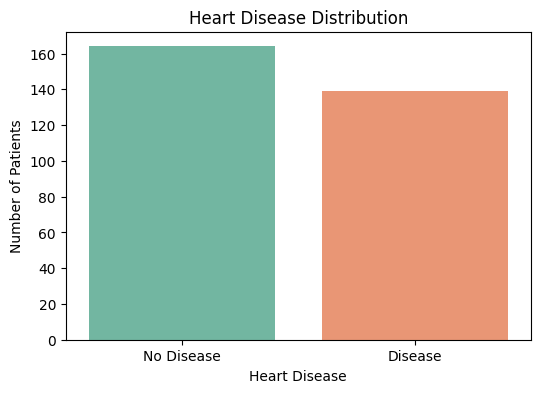

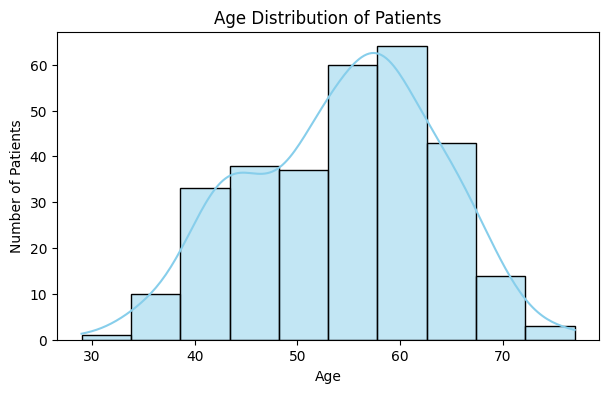

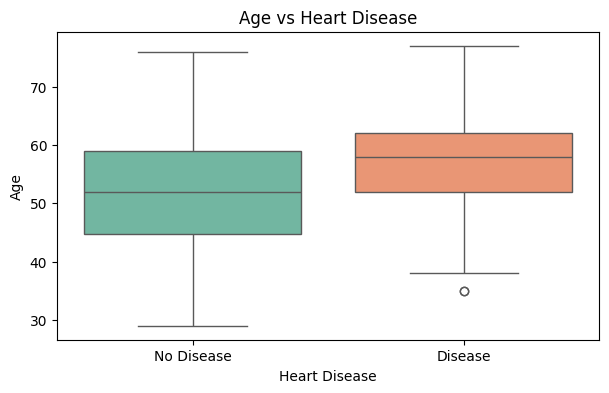

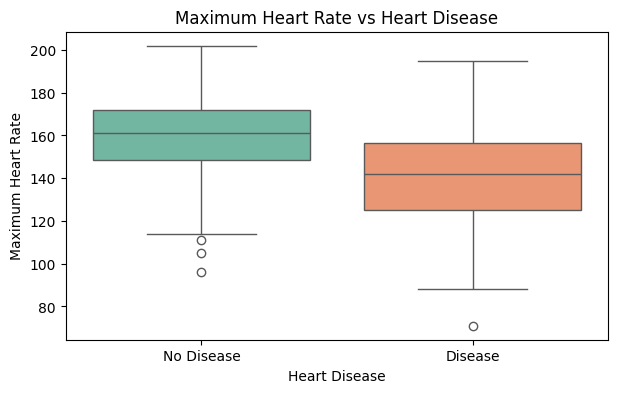

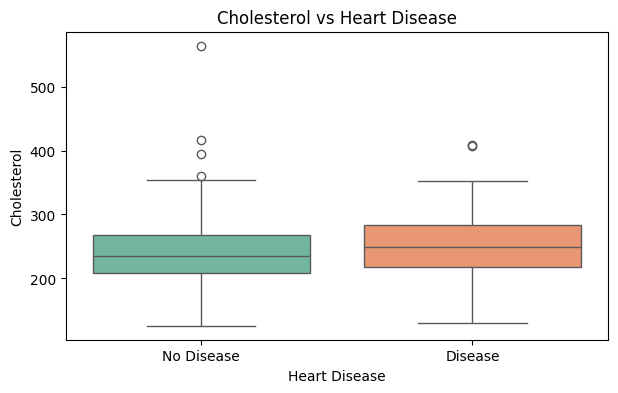

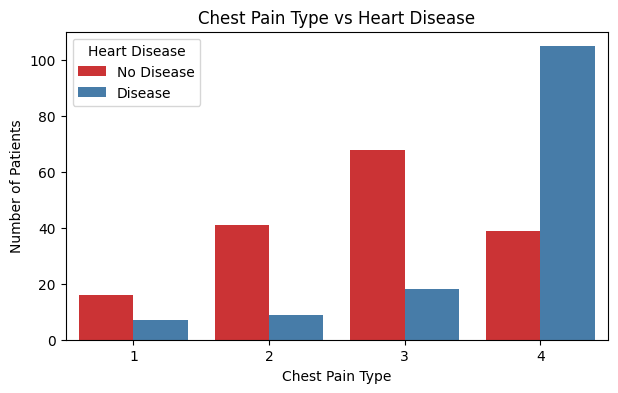

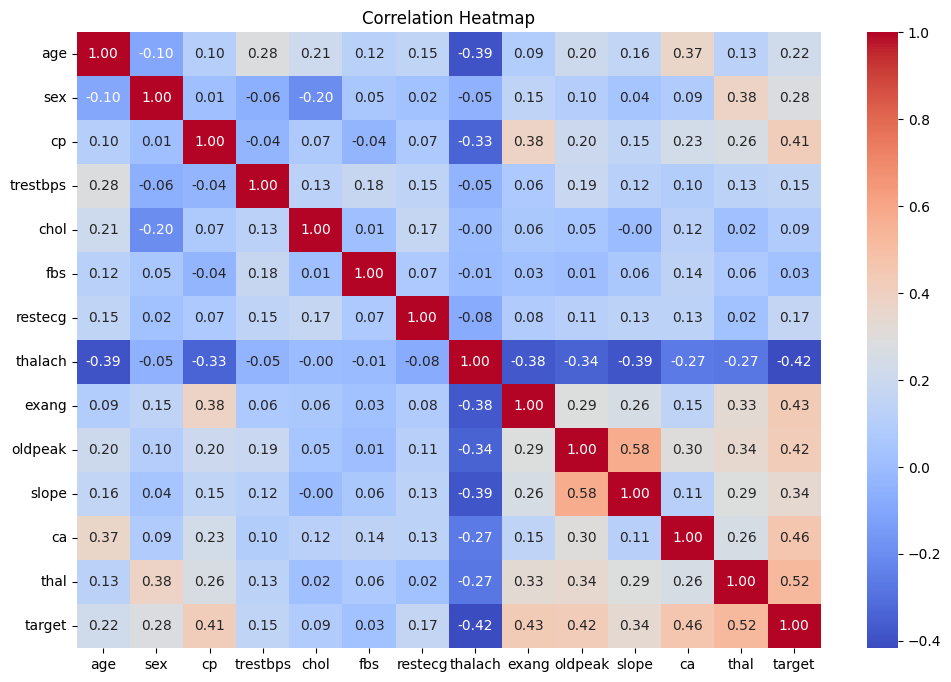


       FEATURES AND TARGET

Features:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

Target:
0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

          TRAIN TEST SPLIT

Training data size: (242, 13)
Testing data size : (61, 13)

Training samples: 242
Testing samples : 61

Model training completed!

           PREDICTIONS

Predicted values:
[0 1 0 0 0 0 1 0 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 1 0 1 0
 0 0 0 1 1 1 1 0 0 1 0 1 1 0 1 1 0 1

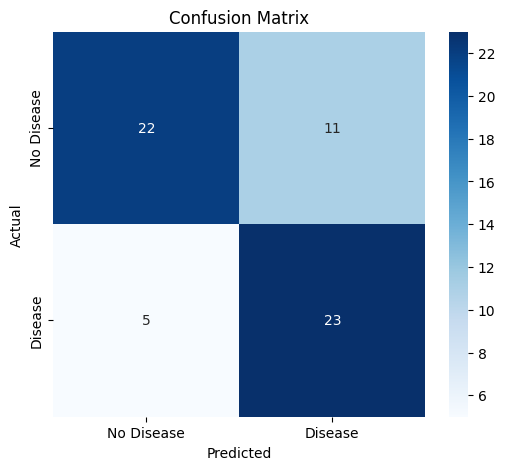

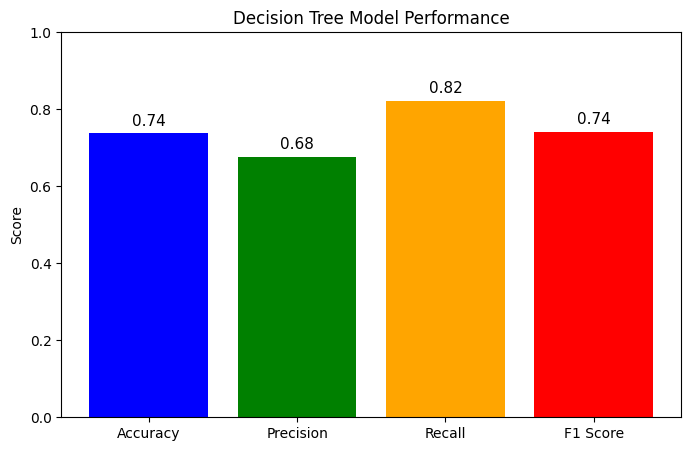


         FEATURE IMPORTANCE
     Feature  Importance
12      thal    0.295397
2         cp    0.126362
0        age    0.117906
11        ca    0.104556
9    oldpeak    0.094425
4       chol    0.075819
7    thalach    0.071414
1        sex    0.031690
10     slope    0.025014
8      exang    0.023537
3   trestbps    0.017435
5        fbs    0.016444
6    restecg    0.000000


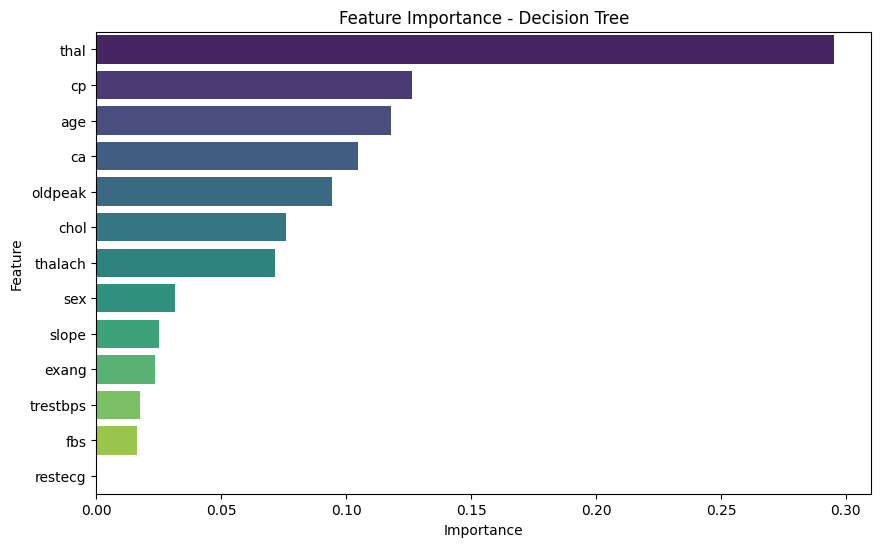

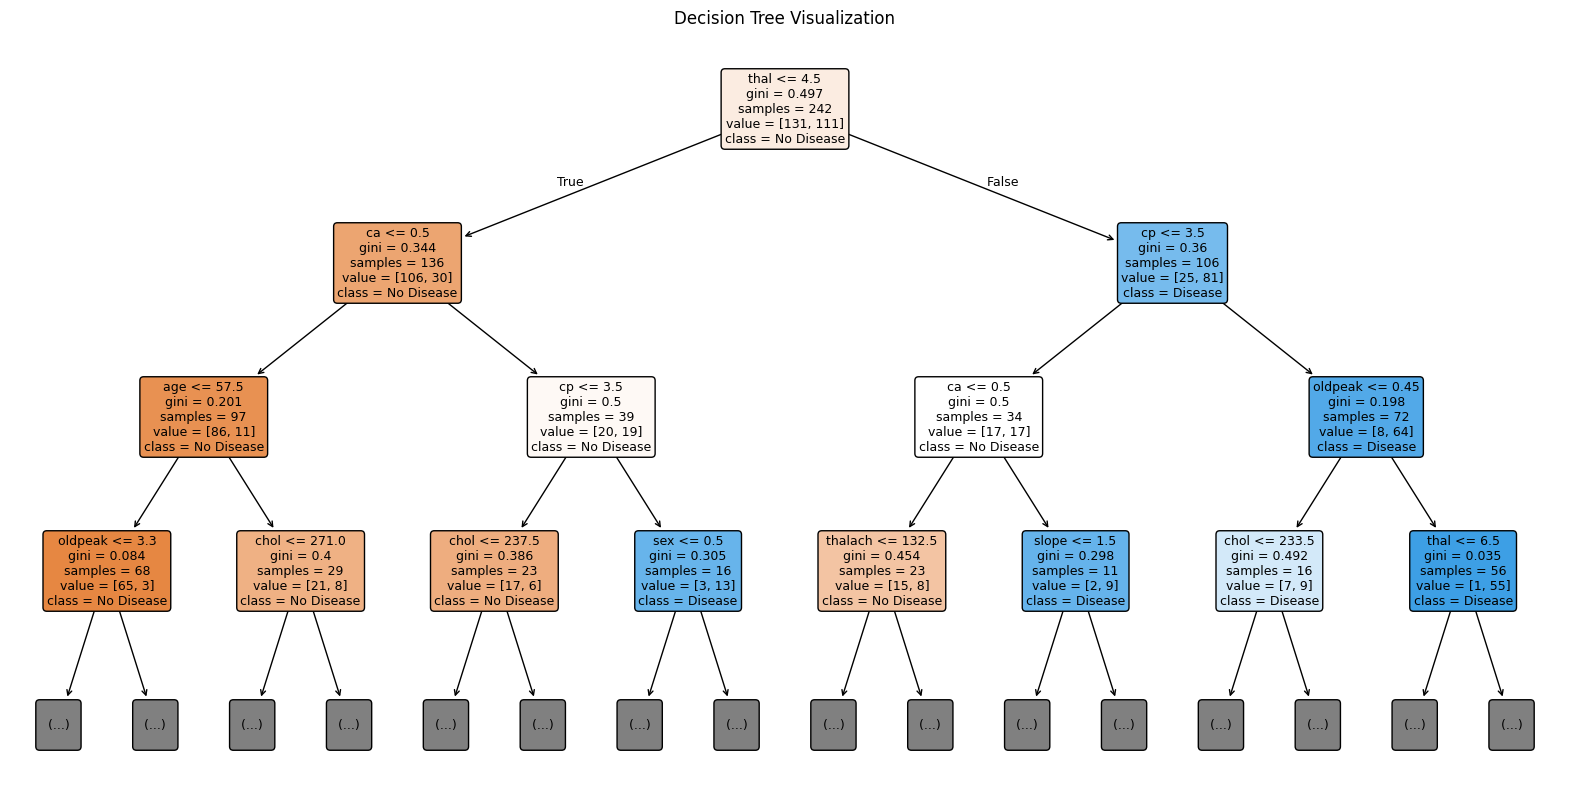


           FINAL RESULTS
Dataset size       : (303, 14)
Training samples   : 242
Testing samples    : 61
------------------------------------
Accuracy            : 0.74
Precision           : 0.68
Recall              : 0.82
F1 Score            : 0.74
------------------------------------
Confusion Matrix:
[[22 11]
 [ 5 23]]
       PROGRAM COMPLETED


In [2]:
# ============================================================
# HEART DISEASE PREDICTION USING SUPERVISED LEARNING
# DECISION TREE CLASSIFIER
# GOOGLE COLAB VERSION
# ============================================================


# ============================================================
# 1. INSTALL REQUIRED DATASET PACKAGE
# ============================================================

!pip -q install ucimlrepo


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 3. LOAD HEART DISEASE DATASET
# ============================================================

print("Loading Heart Disease dataset...")

heart_disease = fetch_ucirepo(id=45)

# Get feature data
X = heart_disease.data.features.copy()

# Get target data
y = heart_disease.data.targets.copy()

print("Dataset loaded successfully!")


# ============================================================
# 4. PREPARE DATASET
# ============================================================

# Convert target to a Series
y = y.iloc[:, 0]

# The original UCI target:
# 0 = no heart disease
# 1,2,3,4 = heart disease
#
# Convert it into binary classification:
# 0 = No Disease
# 1 = Disease

y = y.apply(lambda value: 0 if value == 0 else 1)

# Combine features and target
df = X.copy()
df["target"] = y


# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Convert possible missing values to NaN
df = df.replace("?", pd.NA)

# Convert all columns to numeric where possible
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Fill missing numerical values with median
df = df.fillna(df.median(numeric_only=True))

print("\nMissing values after cleaning:")
print(df.isnull().sum())


# ============================================================
# 6. DISPLAY DATASET INFORMATION
# ============================================================

print("\n====================================")
print("       DATASET INFORMATION")
print("====================================")

print("\nFirst 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nTarget value counts:")
print(df["target"].value_counts())


# ============================================================
# 7. HEART DISEASE DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    x="target",
    data=df,
    hue="target",
    palette="Set2",
    legend=False
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()


# ============================================================
# 8. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 4))

sns.histplot(
    df["age"],
    bins=10,
    kde=True,
    color="skyblue"
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


# ============================================================
# 9. AGE VS HEART DISEASE
# ============================================================

plt.figure(figsize=(7, 4))

sns.boxplot(
    x="target",
    y="age",
    data=df,
    hue="target",
    palette="Set2",
    legend=False
)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()


# ============================================================
# 10. MAXIMUM HEART RATE VS HEART DISEASE
# ============================================================

plt.figure(figsize=(7, 4))

sns.boxplot(
    x="target",
    y="thalach",
    data=df,
    hue="target",
    palette="Set2",
    legend=False
)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()


# ============================================================
# 11. CHOLESTEROL VS HEART DISEASE
# ============================================================

plt.figure(figsize=(7, 4))

sns.boxplot(
    x="target",
    y="chol",
    data=df,
    hue="target",
    palette="Set2",
    legend=False
)

plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()


# ============================================================
# 12. CHEST PAIN TYPE VS HEART DISEASE
# ============================================================

plt.figure(figsize=(7, 4))

sns.countplot(
    x="cp",
    hue="target",
    data=df,
    palette="Set1"
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.legend(
    title="Heart Disease",
    labels=["No Disease", "Disease"]
)

plt.show()


# ============================================================
# 13. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


# ============================================================
# 14. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("target", axis=1)
y = df["target"]

print("\n====================================")
print("       FEATURES AND TARGET")
print("====================================")

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())


# ============================================================
# 15. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n====================================")
print("          TRAIN TEST SPLIT")
print("====================================")

print("\nTraining data size:", X_train.shape)
print("Testing data size :", X_test.shape)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 16. CREATE DECISION TREE CLASSIFIER
# ============================================================

model = DecisionTreeClassifier(
    random_state=42
)


# ============================================================
# 17. TRAIN THE MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nModel training completed!")


# ============================================================
# 18. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\n====================================")
print("           PREDICTIONS")
print("====================================")

print("\nPredicted values:")
print(y_pred)


# ============================================================
# 19. CALCULATE EVALUATION METRICS
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# ============================================================
# 20. DISPLAY MODEL EVALUATION
# ============================================================

print("\n====================================")
print("          MODEL EVALUATION")
print("====================================")

print("Accuracy  :", round(accuracy, 2))
print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))
print("F1 Score  :", round(f1, 2))


# ============================================================
# 21. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 22. VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================================
# 23. PERFORMANCE METRICS GRAPH
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

scores = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metrics,
    scores,
    color=["blue", "green", "orange", "red"]
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Decision Tree Model Performance")

for bar, score in zip(bars, scores):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.2f}",
        ha="center",
        fontsize=11
    )

plt.show()


# ============================================================
# 24. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n====================================")
print("         FEATURE IMPORTANCE")
print("====================================")

print(feature_importance)


# ============================================================
# 25. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance,
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()


# ============================================================
# 26. VISUALIZE DECISION TREE
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    max_depth=3,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Visualization")

plt.show()


# ============================================================
# 27. FINAL RESULTS
# ============================================================

print("\n====================================")
print("           FINAL RESULTS")
print("====================================")

print("Dataset size       :", df.shape)
print("Training samples   :", len(X_train))
print("Testing samples    :", len(X_test))

print("------------------------------------")

print("Accuracy            :", round(accuracy, 2))
print("Precision           :", round(precision, 2))
print("Recall              :", round(recall, 2))
print("F1 Score            :", round(f1, 2))

print("------------------------------------")

print("Confusion Matrix:")
print(cm)

print("====================================")
print("       PROGRAM COMPLETED")
print("====================================")
